In [4]:
import os 
import sys
import urllib
from zipfile import ZipFile

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib inline

import cv2 as cv

In [25]:
video_input_file = "../Images/Cars.mp4"

def drawRectange(frame, bbox):
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv.rectangle(frame, p1, p2, (0, 255,0), 2, 1)
    
def displayRectangle(frame, bbox):
    plt.figure(figsize=(20,10))
    frameCopy = frame.copy()
    drawRectange(frameCopy, bbox)
    frameCopy = cv.cvtColor(frameCopy, cv.COLOR_RGB2BGR)
    plt.imshow(frameCopy);#plt.axis('off');

def drawText(frame, text, location, color=(50, 170, 50)):
    cv.putText(frame, text, location, cv.FONT_HERSHEY_COMPLEX, 1, color, 3)


In [17]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urllib.request.urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

URL = r"https://www.dropbox.com/s/ld535c8e0vueq6x/opencv_bootcamp_assets_NB11.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB11.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

- Create tracker instance.

In [26]:
tracker_types = ["BOOSTING", "MIL", "KCF", 
                 "CSRT", "TLD", "MEDIANFLOW",
                 "GOTURN", "MOSSE"]

tracker_type = tracker_types[3]

if tracker_type == "BOOSTING":
    tracker = cv.legacy_TrackerBoosting.create()
elif tracker_type == "MIL":
    tracker = cv.TrackerMIL_create()
elif tracker_type == "KCF":
    tracker = cv.TrackerKCF_create()
elif tracker_type == "CSRT":
    tracker = cv.legacy_TrackerCSRT.create()
elif tracker_type == "TLD":
    tracker = cv.legacy_TrackerTLD.create()
elif tracker_type == "MEDIANFLOW":
    tracker = cv.legacyTrackerMedianFlow.create()
elif tracker_type == "GOTURN":
    tracker = cv.TrackerGOTURN_create()
else:
    tracker = cv.legacy_TrackerMOSSE.create()

- Read input and setup output video.

In [34]:
video = cv.VideoCapture(video_input_file)
ret, frame = video.read()

if not video.isOpened():
    print("Could not open video file.")
    sys.exit()
else:
    width = int(video.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv.CAP_PROP_FRAME_HEIGHT))

video_output_file = "cars" + tracker_type + '.mp4'
video_out = cv.VideoWriter(video_output_file, cv.VideoWriter_fourcc(*'mp4v'), 10, (width, height))

- Define bounding box.

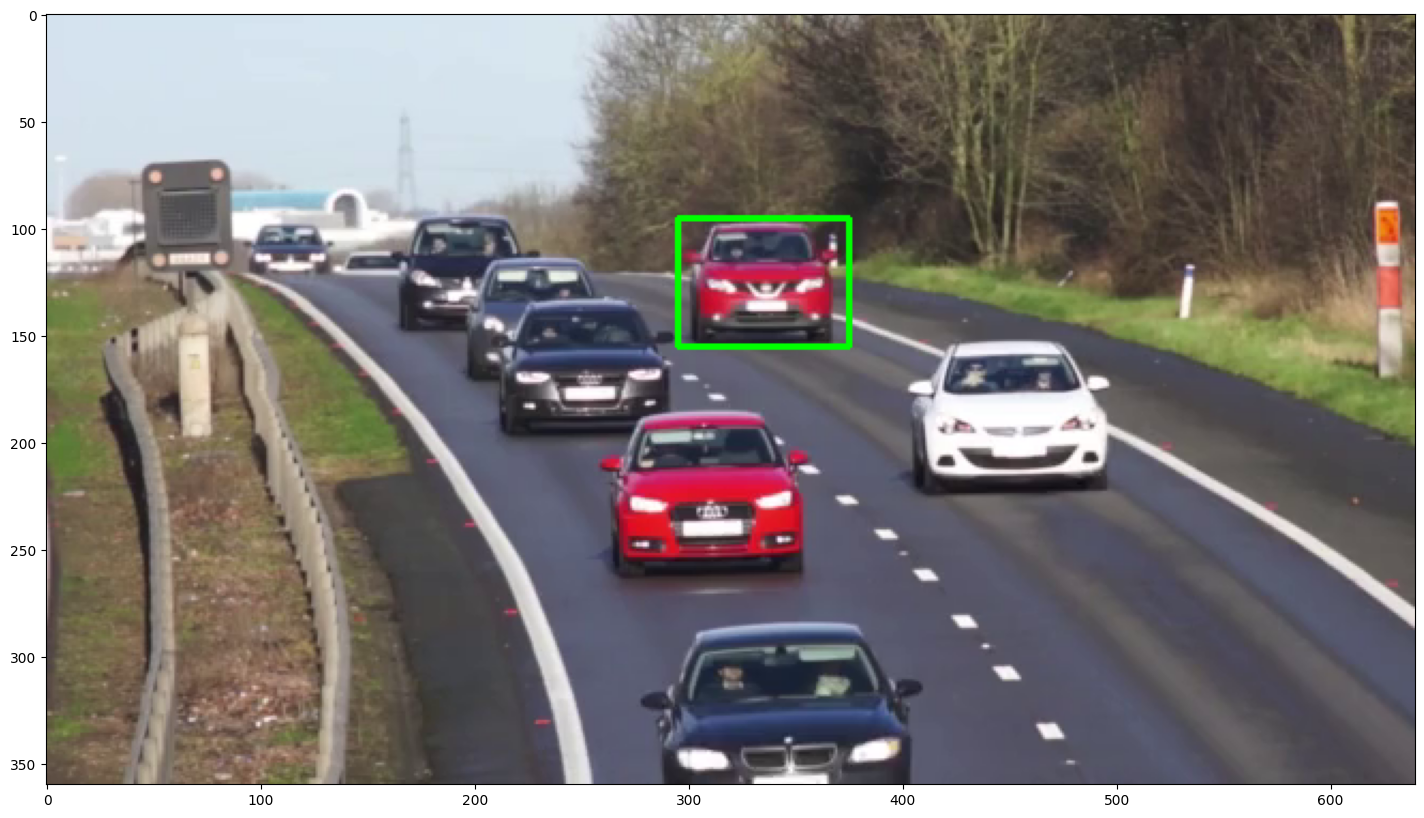

In [35]:
bbox = (295, 95, 80, 60)
#bbox = cv.selectROI(frame, bbox)
#print(bbox)

displayRectangle(frame, bbox)

- Initialize tracker.

In [36]:
#Initialize the tacker with the first frame and bounding box.
ok =tracker.init(frame, bbox)

In [37]:
#Read subsequent frames andtrack object.
while True:
    ok, frame = video.read()

    if not ok:
        break

    #start timer.
    timer = cv.getTickCount()

    #Update tracker.
    ok, bbox = tracker.update(frame)

    #Calculate frames per second.
    fps = cv.getTickFrequency() / (cv.getTickCount() - timer)

    #Draw bounding box.
    if ok:
        drawRectange(frame, bbox)
    else:
        drawText(frame, "Tracking failure detected", (80, 140), (0, 0, 255))
    

    #Display info.
    drawText(frame, tracker_type + "Tracker", (80, 60))
    drawText(frame, "FPS: " + str(int(fps)), (80, 100))

    #Write frame to video
    video_out.write(frame)

video.release()
video_out.release()

In [38]:
from IPython.display import HTML

HTML("""
<video width=1024 controls>
    <source src={} type="video/mp4">
</video> 
""".format(video_output_file)
)